Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

Data Collection and Analysis

PIMA Diabetes Dataset

In [2]:
# loading the diabetes dataset to a pandas DataFrame
diabetes_dataset = pd.read_csv("../Datasets/data/diabetes.csv")

In [3]:
# printing the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# number of rows and Columns in this dataset
diabetes_dataset.shape

(4500, 9)

In [5]:
# getting the statistical measures of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,2.796667,121.516667,71.729778,27.594000,149.088667,32.194578,0.465489,34.895333,0.339111
std,3.280641,30.466608,14.132823,12.307493,118.141549,6.981211,0.306735,12.959730,0.473460
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,0.000000,100.000000,63.000000,20.000000,60.750000,27.400000,0.243000,24.000000,0.000000
50%,2.000000,119.000000,72.000000,27.000000,123.500000,32.100000,0.390500,31.000000,0.000000
75%,4.000000,142.000000,81.000000,35.000000,211.250000,36.700000,0.607000,42.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    2974
1    1526
Name: count, dtype: int64

0 --> Non-Diabetic

1 --> Diabetic

In [7]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,2.648958,115.129792,71.179220,27.380968,146.469401,31.193578,0.444447,33.230666
1,3.084535,133.963958,72.802752,28.009174,154.193316,34.145413,0.506497,38.139581


In [8]:
# separating the data and labels
X = diabetes_dataset.drop(columns = 'Outcome', axis=1)
Y = diabetes_dataset['Outcome']

In [9]:
print(X)

      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0               6      148             72             35        0  33.6   
1               1       85             66             29        0  26.6   
2               8      183             64              0        0  23.3   
3               1       89             66             23       94  28.1   
4               0      137             40             35      168  43.1   
...           ...      ...            ...            ...      ...   ...   
4495           15       81             73             37      155  26.5   
4496            1      115             90             33      138  31.4   
4497            0      114             57             35      188  33.7   
4498            2      163             91             26       40  41.8   
4499            1      121             79             36      182  44.2   

      DiabetesPedigreeFunction  Age  
0                        0.627   50  
1                      

In [10]:
print(Y)

0       1
1       0
2       1
3       0
4       1
       ..
4495    0
4496    0
4497    1
4498    1
4499    1
Name: Outcome, Length: 4500, dtype: int64


Train Test Split

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=2)

In [12]:
print(X.shape, X_train.shape, X_test.shape)

(4500, 8) (3600, 8) (900, 8)


Training the Model

In [13]:
classifier = svm.SVC(kernel='linear')

In [14]:
#training the support vector Machine Classifier
classifier.fit(X_train, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Accuracy Score

In [15]:
# accuracy score on the training data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [16]:
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.6955555555555556


In [17]:
# accuracy score on the test data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [18]:
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.6855555555555556


Making a Predictive System

In [19]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = classifier.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[0]
The person is not diabetic


c:\Users\sahil\OneDrive\Desktop\CODE\Trail\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Saving the trained model

In [20]:
import pickle

In [21]:
filename = 'diabetes_model.sav'
pickle.dump(classifier, open(filename, 'wb'))

In [22]:
# loading the saved model
loaded_model = pickle.load(open('diabetes_model.sav', 'rb'))

In [23]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = loaded_model.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[0]
The person is not diabetic


c:\Users\sahil\OneDrive\Desktop\CODE\Trail\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [24]:
for column in X.columns:
  print(column)

Pregnancies
Glucose
BloodPressure
SkinThickness
Insulin
BMI
DiabetesPedigreeFunction
Age


# Model Performance Visualization & Analysis
This section includes comprehensive visualizations for training accuracy, confusion matrix, ROC curve, and system architecture.

In [25]:
# Create output directory for graphs
os.makedirs('../ML/graphs', exist_ok=True)

# Calculate additional metrics
precision = precision_score(Y_test, X_test_prediction)
recall = recall_score(Y_test, X_test_prediction)
f1 = f1_score(Y_test, X_test_prediction)

print(f"Training Accuracy: {training_data_accuracy:.4f}")
print(f"Test Accuracy: {test_data_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Training Accuracy: 0.6956
Test Accuracy: 0.6856
Precision: 0.5902
Recall: 0.2361
F1 Score: 0.3372


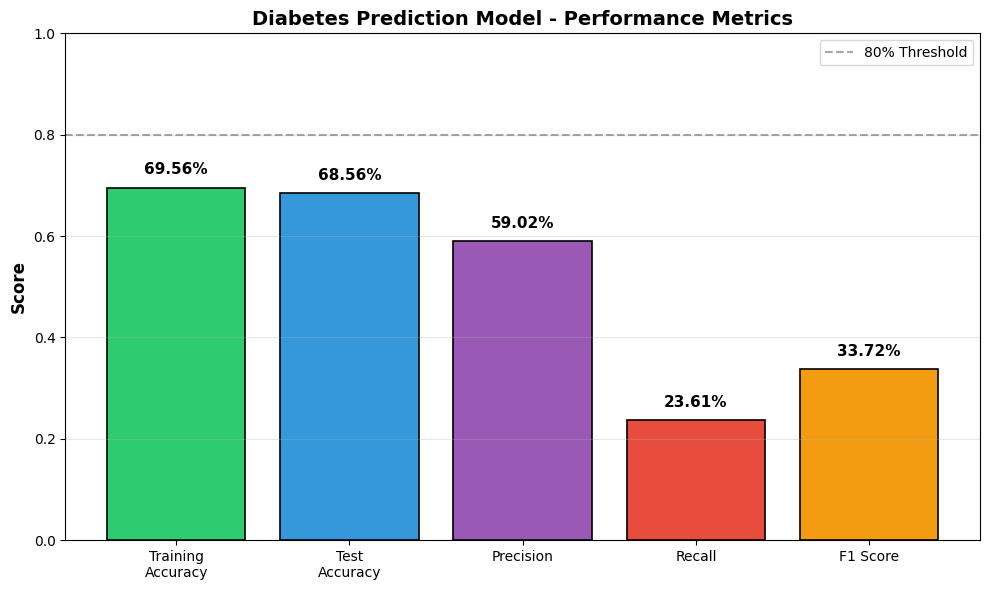

✅ Graph saved to: graphs/diabetes_performance_metrics.png


In [26]:
# 1. Training vs Test Accuracy Bar Graph
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Training\nAccuracy', 'Test\nAccuracy', 'Precision', 'Recall', 'F1 Score']
values = [training_data_accuracy, test_data_accuracy, precision, recall, f1]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12']

bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.2)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Diabetes Prediction Model - Performance Metrics', fontsize=14, fontweight='bold')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.7, label='80% Threshold')

# Add value labels on bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../ML/graphs/diabetes_performance_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/diabetes_performance_metrics.png")

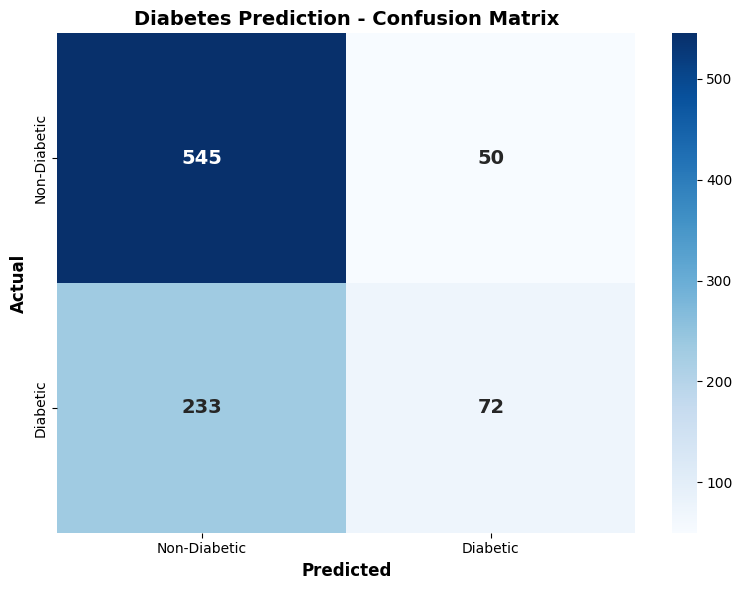

✅ Graph saved to: graphs/diabetes_confusion_matrix.png


In [27]:
# 2. Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Diabetes Prediction - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../ML/graphs/diabetes_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/diabetes_confusion_matrix.png")

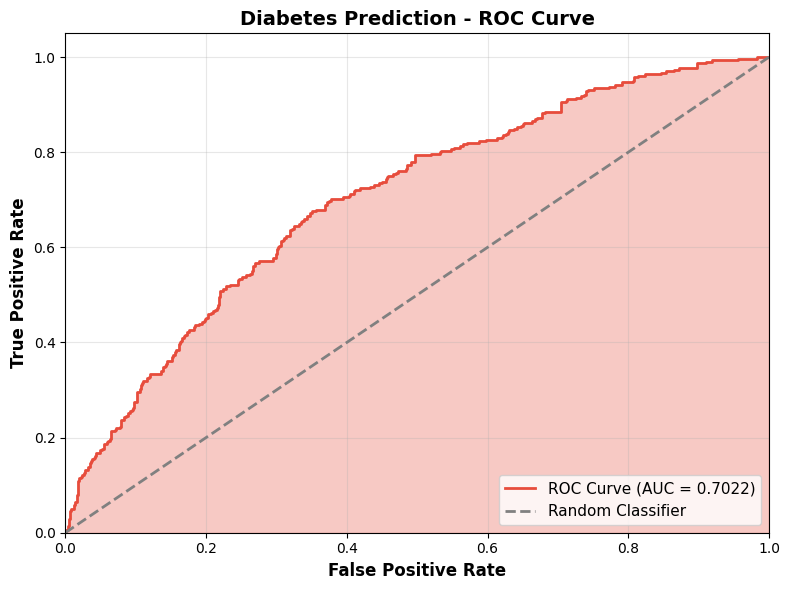

✅ Graph saved to: graphs/diabetes_roc_curve.png


In [28]:
# 3. ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
# Get decision function scores for ROC curve
y_scores = classifier.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(Y_test, y_scores)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('Diabetes Prediction - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../ML/graphs/diabetes_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/diabetes_roc_curve.png")

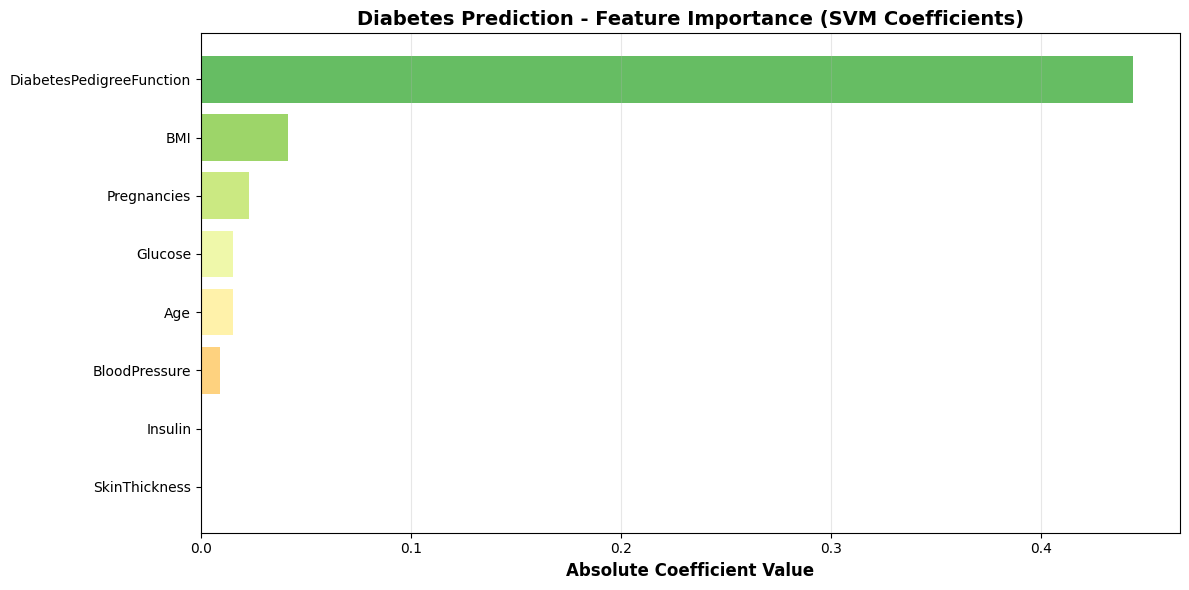

✅ Graph saved to: graphs/diabetes_feature_importance.png


In [29]:
# 4. Feature Importance (based on SVM coefficients)
fig, ax = plt.subplots(figsize=(12, 6))
feature_names = X.columns.tolist()
coefficients = classifier.coef_[0]
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefficients)
}).sort_values('Importance', ascending=True)

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importance_df)))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
ax.set_xlabel('Absolute Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('Diabetes Prediction - Feature Importance (SVM Coefficients)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../ML/graphs/diabetes_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to: graphs/diabetes_feature_importance.png")

In [30]:
# 5. Download Diabetes Graphs as ZIP
import zipfile
from pathlib import Path

def create_diabetes_graphs_zip():
    """Create a downloadable ZIP file containing diabetes model graphs."""
    graphs_dir = Path('../ML/graphs')
    zip_path = graphs_dir / 'diabetes_graphs.zip'
    
    if graphs_dir.exists():
        graph_files = [f for f in graphs_dir.glob('diabetes_*.png')]
        
        if graph_files:
            with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
                for graph_file in graph_files:
                    zipf.write(graph_file, graph_file.name)
            
            print(f"📦 Created ZIP archive with {len(graph_files)} diabetes graphs:")
            for gf in sorted(graph_files):
                print(f"   ✓ {gf.name}")
            print(f"\n📥 Download from: {zip_path.absolute()}")
            return str(zip_path.absolute())
        else:
            print("⚠️ No diabetes graph files found. Run visualization cells first.")
    return None

create_diabetes_graphs_zip()

📦 Created ZIP archive with 4 diabetes graphs:
   ✓ diabetes_confusion_matrix.png
   ✓ diabetes_feature_importance.png
   ✓ diabetes_performance_metrics.png
   ✓ diabetes_roc_curve.png

📥 Download from: c:\Users\sahil\OneDrive\Desktop\CODE\Trail\ML\..\ML\graphs\diabetes_graphs.zip


'c:\\Users\\sahil\\OneDrive\\Desktop\\CODE\\Trail\\ML\\..\\ML\\graphs\\diabetes_graphs.zip'